# 00 - Data Loading and Audit

## Objetivo
Este notebook se encarga exclusivamente de:

- cargar el dataset original,
- inspeccionar su estructura,
- revisar tipos de dato,
- identificar valores faltantes,
- detectar duplicados,
- encontrar columnas problemáticas,
- documentar observaciones para el pipeline posterior.

## Alcance
Este notebook **no debe**:

- entrenar modelos,
- aplicar PCA,
- escalar variables,
- hacer split train/test definitivo.

## Resultado esperado
Al finalizar este notebook debemos tener claro:

1. Qué columnas existen.
2. Qué columnas tienen nulos.
3. Qué columnas requieren conversión de tipo.
4. Qué variables podrían causar fuga de información.
5. Qué limpieza mínima necesita el dataset antes del modelado.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

## 1. Configuración de rutas

Aquí se define la ruta al dataset original.  
La idea es evitar rutas rígidas de Colab o Google Drive y usar una ruta relativa al proyecto.

In [7]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

DATASET_PATH = RAW_DIR / "final_combined_data_v3.csv"  # Cambiar por el nombre real

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH :", DATASET_PATH)
print("Existe archivo:", DATASET_PATH.exists())

PROJECT_ROOT: C:\Users\PC\Documents\GitHub\ProyectoGranja
DATASET_PATH : C:\Users\PC\Documents\GitHub\ProyectoGranja\data\raw\final_combined_data_v3.csv
Existe archivo: True


## 2. Carga del dataset

In [8]:
def LoadDataset(dataset_path: Path) -> pd.DataFrame:
    if not dataset_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {dataset_path}")

    encodings_to_try = ["utf-8", "latin1", "cp1252"]

    last_error = None
    for encoding in encodings_to_try:
        try:
            df = pd.read_csv(dataset_path, encoding=encoding)
            print(f"Dataset cargado con encoding: {encoding}")
            return df
        except Exception as exc:
            last_error = exc

    raise last_error


df = LoadDataset(DATASET_PATH)

Dataset cargado con encoding: latin1


In [9]:
print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (3855, 22)


,Fecha consumo,Corral,Consumo Corral,Pasta de soya seco,Maiz molido seco,Silo de Maiz seco,Silo de Avena seco,Triticale_seca,PataCebada_seca,OroMilk_seca,Melaza_seca,Oro Balance seco,Agua_kg,Total_MS_Dieta Seco,consumo (kg),sobrante (kg),% rechazo,Fecha Ordeño,ID_vaca,Produccion_total_kg,Numero_Ordeños,Corral de ordeño
0,01/01/2025,1.0000,"1,000.0000",0.0000,0.0000,0.0000,0.0000,7.8000,0.4000,14.1800,1.3300,0.0000,5.5000,23.7000,"1,000.0000",0,0%,01/01/2025,1213,18.9900,1,Corral 1 y 2
1,01/01/2025,2.0000,"1,300.0000",0.0000,0.0000,0.0000,0.0000,7.8000,0.4000,14.1800,1.3300,0.0000,5.5000,23.7000,"1,300.0000",0,0%,01/01/2025,1216,13.9600,1,Corral 1 y 2
2,01/01/2025,3.0000,"1,200.0000",0.0000,0.0000,0.0000,0.0000,7.8000,0.4000,14.1800,1.3300,0.0000,5.5000,23.7000,"1,200.0000",0,0%,01/01/2025,1228,16.5600,1,Corral 3 y 4
3,01/01/2025,4.0000,"1,290.0000",0.0000,0.0000,0.0000,0.0000,7.8000,0.4000,14.1800,1.3300,0.0000,5.5000,23.7000,"1,290.0000",10,1%,01/01/2025,1235,14.2600,1,Corral 3 y 4
4,01/01/2025,5.0000,"1,200.0000",0.0000,0.0000,0.0000,0.0000,7.8000,0.4000,14.1800,1.3300,0.0000,5.5000,23.7000,"1,200.0000",0,0%,01/01/2025,1236,13.5400,1,Corral 5 y 6


## 3. Vista general del dataset

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3855 entries, 0 to 3854
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fecha consumo        1608 non-null   str    
 1   Corral               1608 non-null   float64
 2   Consumo Corral       1569 non-null   float64
 3   Pasta de soya seco   1608 non-null   float64
 4   Maiz molido seco     1608 non-null   float64
 5   Silo de Maiz seco    1608 non-null   float64
 6   Silo de Avena seco   1608 non-null   float64
 7   Triticale_seca       1608 non-null   float64
 8   PataCebada_seca      1608 non-null   float64
 9   OroMilk_seca         1608 non-null   float64
 10  Melaza_seca          1608 non-null   float64
 11  Oro Balance seco     1608 non-null   float64
 12  Agua_kg              1608 non-null   float64
 13  Total_MS_Dieta Seco  1608 non-null   float64
 14  consumo (kg)         1608 non-null   float64
 15  sobrante (kg)        1355 non-null   str    
 16 

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Fecha consumo,1608,268,01/01/2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Corral,"1,608.0000",NaN,NaN,NaN,3.5000,1.7084,1.0000,2.0000,3.5000,5.0000,6.0000
Consumo Corral,"1,569.0000",NaN,NaN,NaN,"1,225.7642",427.6545,-170.0000,960.0000,"1,170.0000","1,400.0000","6,515.0000"
Pasta de soya seco,"1,608.0000",NaN,NaN,NaN,0.1045,0.2033,0.0000,0.0000,0.0000,0.0000,0.5000
Maiz molido seco,"1,608.0000",NaN,NaN,NaN,0.4179,0.8134,0.0000,0.0000,0.0000,0.0000,2.0000
Silo de Maiz seco,"1,608.0000",NaN,NaN,NaN,0.4179,0.8134,0.0000,0.0000,0.0000,0.0000,2.0000
Silo de Avena seco,"1,608.0000",NaN,NaN,NaN,1.8325,3.5667,0.0000,0.0000,0.0000,0.0000,8.7700
Triticale_seca,"1,608.0000",NaN,NaN,NaN,6.6709,3.5422,0.0000,7.8000,7.8000,7.8000,10.0000
PataCebada_seca,"1,608.0000",NaN,NaN,NaN,0.3563,0.0496,0.3000,0.3000,0.4000,0.4000,0.4000
OroMilk_seca,"1,608.0000",NaN,NaN,NaN,11.2030,3.3985,6.8500,7.8300,14.1800,14.1800,14.1800


## 4. Nombres de columnas

In [12]:
columns_df = pd.DataFrame({
    "Column": df.columns,
    "DType": [df[col].dtype for col in df.columns]
})

columns_df

,Column,DType
0,Fecha consumo,str
1,Corral,float64
2,Consumo Corral,float64
3,Pasta de soya seco,float64
4,Maiz molido seco,float64
5,Silo de Maiz seco,float64
6,Silo de Avena seco,float64
7,Triticale_seca,float64
8,PataCebada_seca,float64
9,OroMilk_seca,float64


## 5. Valores faltantes

In [13]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "MissingCount": missing_count,
    "MissingPct": missing_pct,
    "DType": df.dtypes.astype(str)
}).sort_values(by="MissingPct", ascending=False)

missing_df

,MissingCount,MissingPct,DType
sobrante (kg),2500,64.8500,str
% rechazo,2335,60.5700,str
Consumo Corral,2286,59.3000,float64
Pasta de soya seco,2247,58.2900,float64
Corral,2247,58.2900,float64
Fecha consumo,2247,58.2900,str
Silo de Maiz seco,2247,58.2900,float64
Maiz molido seco,2247,58.2900,float64
Silo de Avena seco,2247,58.2900,float64
Triticale_seca,2247,58.2900,float64


In [14]:
missing_df[missing_df["MissingCount"] > 0]

,MissingCount,MissingPct,DType
sobrante (kg),2500,64.8500,str
% rechazo,2335,60.5700,str
Consumo Corral,2286,59.3000,float64
Pasta de soya seco,2247,58.2900,float64
Corral,2247,58.2900,float64
Fecha consumo,2247,58.2900,str
Silo de Maiz seco,2247,58.2900,float64
Maiz molido seco,2247,58.2900,float64
Silo de Avena seco,2247,58.2900,float64
Triticale_seca,2247,58.2900,float64


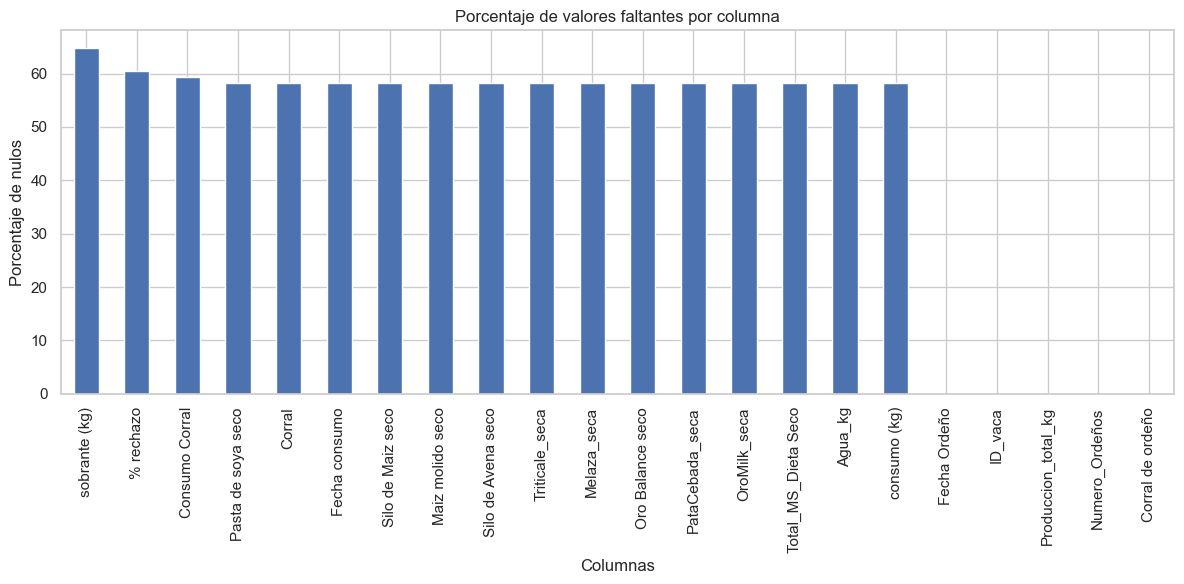

In [15]:
plt.figure(figsize=(12, 6))
missing_df["MissingPct"].plot(kind="bar")
plt.title("Porcentaje de valores faltantes por columna")
plt.ylabel("Porcentaje de nulos")
plt.xlabel("Columnas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 6. Duplicados

In [16]:
duplicate_rows = df.duplicated().sum()
print("Número de filas duplicadas exactas:", duplicate_rows)

Número de filas duplicadas exactas: 0


In [17]:
duplicate_rows = df.duplicated().sum()
print("Número de filas duplicadas exactas:", duplicate_rows)

Número de filas duplicadas exactas: 0


## 7. Revisión de tipos de dato

Aquí buscamos columnas que aparentan ser:

- fechas almacenadas como texto,
- porcentajes almacenados como string,
- variables numéricas almacenadas como object.

In [18]:
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
object_cols

C:\Users\PC\AppData\Local\Temp\ipykernel_23256\2181423088.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=["object"]).columns.tolist()


['Fecha consumo',
 'sobrante (kg)',
 '% rechazo',
 'Fecha Ordeño',
 'Corral de ordeño']

In [19]:
for col in object_cols:
    print("=" * 80)
    print(f"Columna: {col}")
    print(df[col].dropna().astype(str).head(10).tolist())

Columna: Fecha consumo
['01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '02/01/2025', '02/01/2025', '02/01/2025', '02/01/2025']
Columna: sobrante (kg)
['0', '0', '0', '10', '0', '0', '110', '130', '80', '220']
Columna: % rechazo
['0%', '0%', '0%', '1%', '0%', '0%', '10%', '10%', '7%', '17%']
Columna: Fecha Ordeño
['01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025', '01/01/2025']
Columna: Corral de ordeño
['Corral 1 y 2', 'Corral 1 y 2', 'Corral 3 y 4', 'Corral 3 y 4', 'Corral 5 y 6', 'Corral 3 y 4', 'Corral 5 y 6', 'Corral 1 y 2', 'Corral 1 y 2', 'Corral 3 y 4']


## 8. Detección preliminar de columnas fecha

In [20]:
possible_date_cols = [
    col for col in df.columns
    if "fecha" in col.lower() or "date" in col.lower()
]

possible_date_cols

['Fecha consumo', 'Fecha Ordeño']

In [21]:
for col in possible_date_cols:
    print("=" * 80)
    print(f"Columna candidata a fecha: {col}")
    print(df[col].head(10))

Columna candidata a fecha: Fecha consumo
0    01/01/2025
1    01/01/2025
2    01/01/2025
3    01/01/2025
4    01/01/2025
5    01/01/2025
6    02/01/2025
7    02/01/2025
8    02/01/2025
9    02/01/2025
Name: Fecha consumo, dtype: str
Columna candidata a fecha: Fecha Ordeño
0    01/01/2025
1    01/01/2025
2    01/01/2025
3    01/01/2025
4    01/01/2025
5    01/01/2025
6    01/01/2025
7    01/01/2025
8    01/01/2025
9    01/01/2025
Name: Fecha Ordeño, dtype: str


## 9. Conversión tentativa de fechas

Solo para auditoría.  
Todavía no guardamos esta transformación como parte del pipeline final.

In [22]:
df_dates_audit = df.copy()

for col in possible_date_cols:
    try:
        df_dates_audit[col] = pd.to_datetime(df_dates_audit[col], errors="coerce", dayfirst=True)
    except Exception as exc:
        print(f"No se pudo convertir {col}: {exc}")

df_dates_audit[possible_date_cols].head()

,Fecha consumo,Fecha Ordeño
0,2025-01-01,2025-01-01
1,2025-01-01,2025-01-01
2,2025-01-01,2025-01-01
3,2025-01-01,2025-01-01
4,2025-01-01,2025-01-01


In [23]:
for col in possible_date_cols:
    if col in df_dates_audit.columns:
        print("=" * 80)
        print(f"{col}")
        print(df_dates_audit[col].dtype)
        print("NaN tras conversión:", df_dates_audit[col].isna().sum())

Fecha consumo
datetime64[us]
NaN tras conversión: 2247
Fecha Ordeño
datetime64[us]
NaN tras conversión: 0


## 10. Cardinalidad de variables categóricas

Esto ayuda a detectar:

- identificadores,
- columnas de texto libre,
- categorías razonables para encoding,
- columnas demasiado específicas.

In [24]:
categorical_summary = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=True)
    categorical_summary.append({
        "Column": col,
        "DType": str(df[col].dtype),
        "UniqueValues": unique_count
    })

categorical_summary_df = pd.DataFrame(categorical_summary).sort_values(
    by="UniqueValues",
    ascending=False
)

categorical_summary_df

,Column,DType,UniqueValues
19,Produccion_total_kg,float64,2244
2,Consumo Corral,float64,318
14,consumo (kg),float64,310
0,Fecha consumo,str,268
16,% rechazo,str,105
15,sobrante (kg),str,88
17,Fecha Ordeño,str,79
18,ID_vaca,int64,64
1,Corral,float64,6
20,Numero_Ordeños,int64,3


In [25]:
for col in df.columns:
    unique_count = df[col].nunique(dropna=True)
    if unique_count <= 20:
        print("=" * 80)
        print(f"Columna: {col}")
        print(df[col].value_counts(dropna=False).head(20))

Columna: Corral
Corral
NaN       2247
1.0000     268
2.0000     268
3.0000     268
4.0000     268
5.0000     268
6.0000     268
Name: count, dtype: int64
Columna: Pasta de soya seco
Pasta de soya seco
NaN       2247
0.0000    1272
0.5000     336
Name: count, dtype: int64
Columna: Maiz molido seco
Maiz molido seco
NaN       2247
0.0000    1272
2.0000     336
Name: count, dtype: int64
Columna: Silo de Maiz seco
Silo de Maiz seco
NaN       2247
0.0000    1272
2.0000     336
Name: count, dtype: int64
Columna: Silo de Avena seco
Silo de Avena seco
NaN       2247
0.0000    1272
8.7700     336
Name: count, dtype: int64
Columna: Triticale_seca
Triticale_seca
NaN        2247
7.8000      906
10.0000     366
0.0000      336
Name: count, dtype: int64
Columna: PataCebada_seca
PataCebada_seca
NaN       2247
0.4000     906
0.3000     702
Name: count, dtype: int64
Columna: OroMilk_seca
OroMilk_seca
NaN        2247
14.1800     906
7.8300      366
6.8500      336
Name: count, dtype: int64
Columna: Melaz

## 11. Revisión de columnas potencialmente problemáticas

Aquí buscamos columnas que podrían ser:

- identificadores (`ID_vaca`, etc.),
- derivadas del target,
- columnas creadas manualmente en notebooks anteriores,
- columnas con riesgo de fuga de información.

In [26]:
suspicious_patterns = [
    "id",
    "binned",
    "target",
    "produccion",
    "producción"
]

suspicious_cols = [
    col for col in df.columns
    if any(pattern in col.lower() for pattern in suspicious_patterns)
]

suspicious_cols

['Maiz molido seco', 'ID_vaca', 'Produccion_total_kg']

In [27]:
for col in suspicious_cols:
    print("=" * 80)
    print(f"Columna sospechosa: {col}")
    print("DType:", df[col].dtype)
    print("Nulos:", df[col].isna().sum())
    print("Únicos:", df[col].nunique(dropna=True))
    print(df[col].head(10).tolist())

Columna sospechosa: Maiz molido seco
DType: float64
Nulos: 2247
Únicos: 2
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Columna sospechosa: ID_vaca
DType: int64
Nulos: 0
Únicos: 64
[1213, 1216, 1228, 1235, 1236, 1242, 1243, 1555, 1560, 1567]
Columna sospechosa: Produccion_total_kg
DType: float64
Nulos: 0
Únicos: 2244
[18.99, 13.96, 16.56, 14.26, 13.54, 18.01, 11.69, 23.26, 22.19, 40.54]


## 12. Resumen de calidad de datos

In [28]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "DuplicateRows",
        "ColumnsWithMissingValues",
        "TotalMissingValues",
        "ObjectColumns",
        "PossibleDateColumns"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        int(df.duplicated().sum()),
        int((df.isna().sum() > 0).sum()),
        int(df.isna().sum().sum()),
        len(object_cols),
        len(possible_date_cols)
    ]
})

audit_summary

,Metric,Value
0,Rows,3855
1,Columns,22
2,DuplicateRows,0
3,ColumnsWithMissingValues,17
4,TotalMissingValues,38579
5,ObjectColumns,5
6,PossibleDateColumns,2


## 13. Observaciones manuales

Documenta aquí hallazgos importantes para el siguiente notebook.

Ejemplos:
- columnas que deberían convertirse a fecha,
- columnas que podrían eliminarse,
- columnas con demasiados nulos,
- posibles identificadores,
- posibles fugas de información,
- transformaciones necesarias.

### Observaciones iniciales

- [ ] Identificar la columna target oficial.
- [ ] Verificar si existen columnas derivadas del target.
- [ ] Verificar si `ID_vaca` debe excluirse del baseline.
- [ ] Confirmar el formato correcto de fechas.
- [ ] Revisar columnas con alto porcentaje de nulos.
- [ ] Detectar si hay variables categóricas que requieran one-hot encoding.
- [ ] Definir qué columnas deben pasar al notebook de feature engineering.

## 14. Exportar reporte de auditoría

In [29]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

missing_df.to_csv(REPORTS_DIR / "missing_report.csv", index=True)
columns_df.to_csv(REPORTS_DIR / "columns_report.csv", index=False)
categorical_summary_df.to_csv(REPORTS_DIR / "cardinality_report.csv", index=False)
audit_summary.to_csv(REPORTS_DIR / "audit_summary.csv", index=False)

print("Reportes exportados en:", REPORTS_DIR)

Reportes exportados en: C:\Users\PC\Documents\GitHub\ProyectoGranja\reports
